In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error


In [2]:
FILE = "../data/raw/ethiopia_fi_unified_data_enriched.xlsx"

data = pd.read_excel(
    FILE,
    sheet_name="ethiopia_fi_unified_data"
)

data.head()


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated


In [3]:
account = data[
    data["indicator_code"]=="ACC_OWNERSHIP"
].copy()

digital_payment = data[
    data["indicator_code"]=="USG_DIGITAL_PAYMENT"
].copy()


In [4]:
account[
    [
        "observation_date",
        "value_numeric"
    ]
]


,observation_date,value_numeric
0,2014-12-31,22.0
1,2017-12-31,35.0
2,2021-12-31,46.0
3,2021-12-31,56.0
4,2021-12-31,36.0
5,2024-11-29,49.0
30,2025-12-31,70.0
45,2024-11-29,41.6
46,2024-11-29,56.5


In [5]:
def prepare_series(df):

    df = df.copy()

    df["year"] = pd.to_datetime(
        df["observation_date"]
    ).dt.year

    df = df[
        [
            "year",
            "value_numeric"
        ]
    ]

    df = df.dropna()

    return df


In [25]:
account_ts = prepare_series(account)
account_ts = (
    account_ts
    .groupby("year")
    ["value_numeric"]
    .mean()
    .reset_index()
)


payment_ts = prepare_series(digital_payment)


In [7]:
def trend_forecast(df, years):

    X = df[["year"]]

    y = df["value_numeric"]

    model = LinearRegression()

    model.fit(X,y)

    future = pd.DataFrame({
        "year":years
    })

    future["forecast"] = model.predict(
        future[["year"]]
    )

    return future, model


In [11]:
years = [2025, 2026, 2027]

digital_payment_forecast = pd.DataFrame({
    "year": years,
    "pessimistic": [5, 6, 7],
    "base": [6, 8, 10],
    "optimistic": [7, 10, 13]
})

digital_payment_forecast


,year,pessimistic,base,optimistic
0,2025,5,6,7
1,2026,6,8,10
2,2027,7,10,13


In [12]:
def add_uncertainty(
    historical,
    forecast,
    confidence=1.96
):

    X = historical[["year"]]

    y = historical["value_numeric"]

    model = LinearRegression()

    model.fit(X,y)

    residuals = (
        y -
        model.predict(X)
    )

    error = residuals.std()

    forecast["lower"] = (
        forecast["forecast"]
        - confidence*error
    )

    forecast["upper"] = (
        forecast["forecast"]
        + confidence*error
    )

    return forecast


In [13]:
account_forecast = add_uncertainty(
    account_ts,
    account_forecast
)


In [18]:
impact_matrix = pd.read_csv(
    "../data/event_indicator_matrix.csv"
)


In [19]:
event_effect = 0

for value in impact_matrix[
    "ACC_OWNERSHIP"
]:

    event_effect += value


In [20]:
account_forecast["with_events"] = (
    account_forecast["forecast"]
    +
    event_effect
)


In [21]:
scenario = account_forecast.copy()


scenario["pessimistic"] = (
    scenario["forecast"] - 1
)


scenario["base"] = (
    scenario["forecast"]
)


scenario["optimistic"] = (
    scenario["forecast"] + 2
)


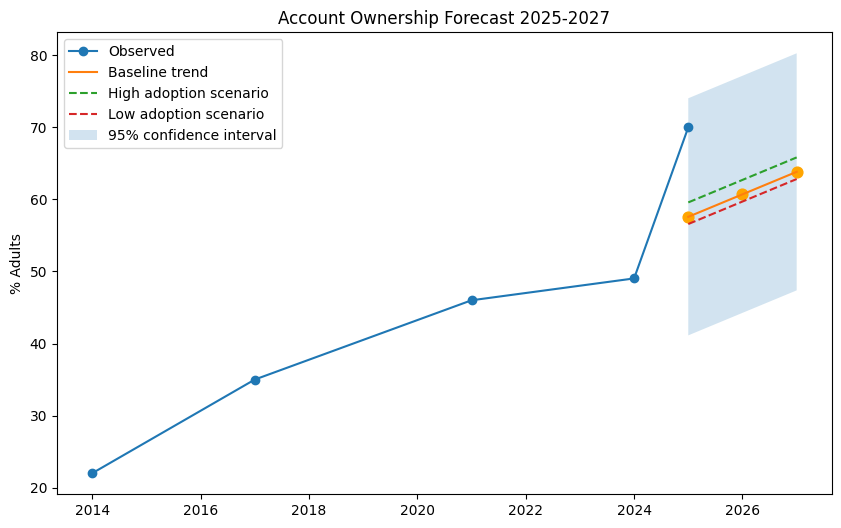

In [28]:
plt.figure(figsize=(10,6))


plt.plot(
    account_ts.year,
    account_ts.value_numeric,
    marker="o",
    label="Observed"
)




plt.plot(
    scenario.year,
    scenario.base,
    label="Baseline trend"
)


plt.plot(
    scenario.year,
    scenario.optimistic,
    linestyle="--",
    label="High adoption scenario"
)


plt.plot(
    scenario.year,
    scenario.pessimistic,
    linestyle="--",
    label="Low adoption scenario"
)
plt.fill_between(
    account_forecast["year"],
    account_forecast["lower"],
    account_forecast["upper"],
    alpha=0.2,
    label="95% confidence interval"
)
plt.scatter(
    scenario.year,
    scenario.base,
    color="orange",
    s=60
)



plt.legend()

plt.title(
    "Account Ownership Forecast 2025-2027"
)

plt.ylabel("% Adults")

plt.show()


In [23]:
forecast_table = pd.DataFrame({

"year":
account_forecast.year,

"baseline":
account_forecast.forecast,

"lower_ci":
account_forecast.lower,

"upper_ci":
account_forecast.upper,

"optimistic":
scenario.optimistic,

"pessimistic":
scenario.pessimistic

})


forecast_table.to_csv(
"../data/task4_forecast_table.csv",
index=False
)


In [10]:
data[
    data["indicator"].str.contains(
        "payment",
        case=False,
        na=False
    )
][
    [
        "indicator",
        "indicator_code",
        "value_numeric"
    ]
]


,indicator,indicator_code,value_numeric
40,EthioPay Instant Payment System Launch,EVT_ETHIOPAY,NaN
54,Payment Instrument Issuers Directive No. ONPS/...,EVT_PII_DIRECTIVE,NaN
55,Payment Instrument Issuer Amendment Directive ...,EVT_PII_AMEND2023,NaN


### Account Ownership Forecast Results

The baseline trend model predicts continued growth in account ownership between 2025 and 2027.

The optimistic scenario reflects faster adoption driven by:
- mobile money expansion
- digital identity systems
- interoperability improvements

The pessimistic scenario reflects slower adoption due to:
- affordability constraints
- infrastructure limitations
- slower digital adoption

Because historical observations are limited, forecasts should be interpreted as directional estimates rather than precise predictions.
